<a href="https://colab.research.google.com/github/BrundaVenkatesh01/flower-classification/blob/main/flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Setup & Data Download

Downloading the Flowers Recognition dataset (4,242 images, 5 classes) from Kaggle using the API. Folder structure = labels

In [2]:
import os

# Update the kaggle tool first — old versions don't know this new token format
!pip install -q -U kaggle

os.environ["KAGGLE_API_TOKEN"] = "Put your kaggle toekn here"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00


In [3]:
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip
import os
os.listdir('flowers')

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:02<00:00, 99.3MB/s]



['sunflower', 'daisy', 'tulip', 'rose', 'dandelion']

Step 2: Explore the dataset

In [4]:
# Count images in each class folder
# Why: if one class had way fewer images (imbalance), the model would ignore it
import os

data_dir = 'flowers'
for cls in os.listdir(data_dir):
    count = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"{cls}: {count} images")

sunflower: 733 images
daisy: 764 images
tulip: 984 images
rose: 784 images
dandelion: 1052 images


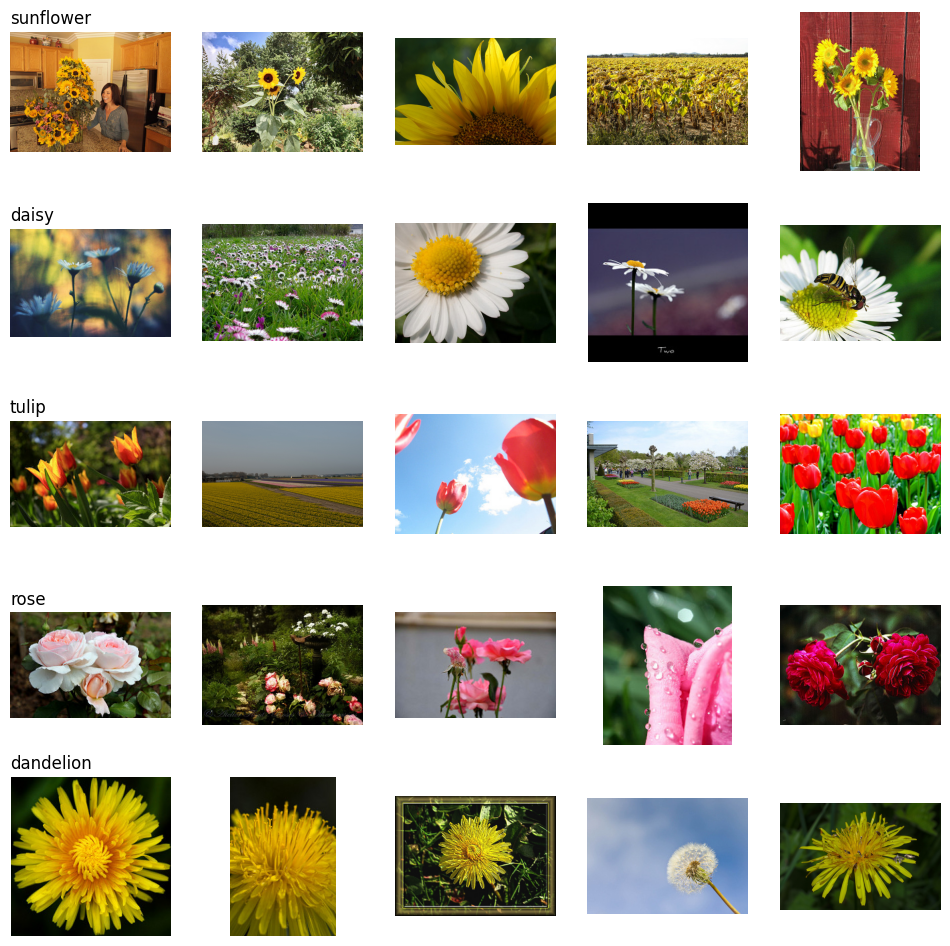

In [5]:
# Show 5 random images from each class
# Why: sanity check — verify labels look right and see what the model will face
import matplotlib.pyplot as plt
import random
from PIL import Image

classes = os.listdir(data_dir)
fig, axes = plt.subplots(len(classes), 5, figsize=(12, 12))

for i, cls in enumerate(classes):
    files = random.sample(os.listdir(os.path.join(data_dir, cls)), 5)
    for j, fname in enumerate(files):
        img = Image.open(os.path.join(data_dir, cls, fname))
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(cls, loc='left')
plt.show()

In [6]:
# Check the size of a few images
# Why: neural networks need all inputs the same size — we'll likely need to resize
for cls in classes[:2]:
    fname = os.listdir(os.path.join(data_dir, cls))[0]
    img = Image.open(os.path.join(data_dir, cls, fname))
    print(cls, img.size)

sunflower (500, 375)
daisy (320, 233)


Step 3a: Transforms + loading the dataset.

In [7]:
# Define the preprocessing recipe applied to every image
# Why: NN needs same-size, normalized numeric inputs — not raw JPGs of random sizes
import torch
from torchvision import transforms, datasets

transform = transforms.Compose([              # Compose = chain steps in order
    transforms.Resize((224, 224)),            # force every image to 224x224
    transforms.ToTensor(),                    # JPG -> tensor, pixels scaled to 0-1
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load dataset: folder names automatically become labels 0-4
dataset = datasets.ImageFolder('flowers', transform=transform)

print(len(dataset))            # total images
print(dataset.classes)         # class names in label order
print(dataset[0][0].shape)     # shape of first image tensor
print(dataset[0][1])           # label of first image (a number)

4317
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
torch.Size([3, 224, 224])
0


Step 3b: Split into train/val/test.

In [8]:
# Split 70/15/15 into train/val/test
# Why fixed seed: same split every run -> results are reproducible
from torch.utils.data import random_split

g = torch.Generator().manual_seed(42)   # seed makes "random" repeatable

n = len(dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val           # remainder, so all three sum to n exactly

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)
print(len(train_ds), len(val_ds), len(test_ds))

3021 647 649


Step 3c: DataLoaders — batching.

In [9]:
# Wrap datasets in DataLoaders: feed model 32 images at a time
# shuffle=True on train only -> model shouldn't learn the order of images
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

# Peek at one batch to verify
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)   # expect [32, 3, 224, 224] and [32]

torch.Size([32, 3, 224, 224]) torch.Size([32])


Step 4: Build the CNN.

In [10]:
# Simple CNN baseline: 3 conv blocks + classifier head
import torch.nn as nn

class FlowerCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 color channels in -> 32 feature maps out
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),        # 224 -> 112

            # Block 2: 32 -> 64 maps (deeper = more complex patterns)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),        # 112 -> 56

            # Block 3: 64 -> 128 maps
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),        # 56 -> 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # [128, 28, 28] -> one long vector
            nn.Linear(128 * 28 * 28, 256),       # compress to 256 numbers
            nn.ReLU(),
            nn.Dropout(0.5),                     # randomly zero 50% during training
            nn.Linear(256, num_classes)          # final 5 scores, one per flower
        )

    def forward(self, x):                        # how data flows through
        x = self.features(x)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlowerCNN().to(device)
print(device)   # should say 'cuda' — if 'cpu', enable GPU in Runtime settings

cuda


Step 5: Training.

In [11]:
# Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
# Train for 10 epochs (1 epoch = one full pass over the training data)
epochs = 8

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()                          # enable training mode (dropout ON)
    train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # move batch to GPU

        optimizer.zero_grad()              # 1. clear old gradients
        outputs = model(images)            # 2. forward pass: get predictions
        loss = criterion(outputs, labels)  # 3. how wrong are we?
        loss.backward()                    # 4. backprop: compute gradients
        optimizer.step()                   # 5. nudge the weights

        train_loss += loss.item()

    # ---- VALIDATE ----
    model.eval()                           # eval mode (dropout OFF)
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():                  # no gradients needed -> faster
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = outputs.argmax(dim=1)          # highest score = prediction
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"train_loss: {train_loss/len(train_loader):.3f} | "
          f"val_loss: {val_loss/len(val_loader):.3f} | "
          f"val_acc: {correct/total:.3f}")

Epoch 1/8 | train_loss: 1.373 | val_loss: 1.151 | val_acc: 0.502
Epoch 2/8 | train_loss: 1.108 | val_loss: 1.070 | val_acc: 0.586
Epoch 3/8 | train_loss: 0.933 | val_loss: 1.037 | val_acc: 0.598
Epoch 4/8 | train_loss: 0.834 | val_loss: 0.994 | val_acc: 0.600
Epoch 5/8 | train_loss: 0.695 | val_loss: 1.029 | val_acc: 0.643
Epoch 6/8 | train_loss: 0.551 | val_loss: 1.129 | val_acc: 0.629
Epoch 7/8 | train_loss: 0.403 | val_loss: 1.230 | val_acc: 0.604
Epoch 8/8 | train_loss: 0.332 | val_loss: 1.387 | val_acc: 0.646


Step 6: Data Augmentation

Adding random transforms (flip, rotation, crop, color jitter) to training images only — fighting the overfitting seen after epoch 5 by making memorization impossible.

In [13]:
# Two recipes: augmented for train, plain for val/test
from torch.utils.data import Subset

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # random zoom/crop
    transforms.RandomHorizontalFlip(),                    # 50% mirror — flowers have no "correct" side
    transforms.RandomRotation(15),                        # tilt up to ±15°
    transforms.ColorJitter(brightness=0.2, saturation=0.2),  # lighting variety
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([                     # same as before — no randomness
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Two views of the same folder, different recipes
train_base = datasets.ImageFolder('flowers', transform=train_transform)
eval_base  = datasets.ImageFolder('flowers', transform=eval_transform)

# Split INDICES with the same seed 42 -> identical split to before
g = torch.Generator().manual_seed(42)
n = len(train_base)
n_train, n_val = int(0.70*n), int(0.15*n)
perm = torch.randperm(n, generator=g).tolist()   # shuffled order of all indices

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:]

train_ds = Subset(train_base, train_idx)   # augmented
val_ds   = Subset(eval_base,  val_idx)     # plain
test_ds  = Subset(eval_base,  test_idx)    # plain

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)
print(len(train_ds), len(val_ds), len(test_ds))   # expect 3021 647 649

3021 647 649


Step 7: Transfer learning with ResNet18

In [14]:
# Step 7: Transfer learning with ResNet18
from torchvision import models

model = models.resnet18(weights='IMAGENET1K_V1')   # download pretrained weights

# Freeze all layers: don't touch the learned features
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer (1000 ImageNet classes -> our 5 flowers)
# A fresh layer is trainable by default — the ONLY part that will learn
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

# Optimizer only needs to update the new layer's weights
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


Step 8: Final evaluation on the test set

In [15]:
# Final test-set evaluation — run ONCE, report this number
model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().tolist())     # save for confusion matrix
        all_labels.extend(labels.cpu().tolist())

print(f"Test accuracy: {correct/total:.3f}")

Test accuracy: 0.190


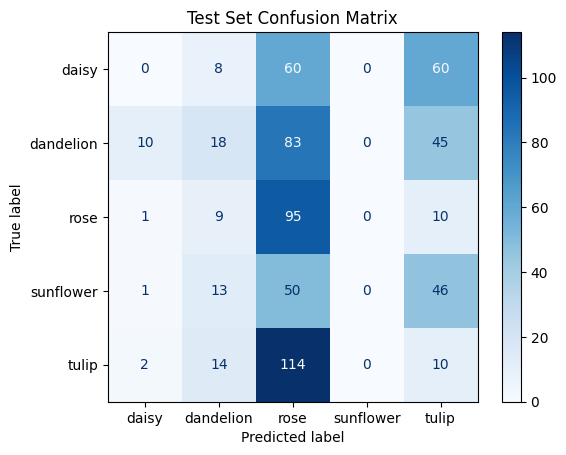

In [16]:
# Confusion matrix: see WHERE the model makes mistakes
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=classes, cmap='Blues'
)
plt.title('Test Set Confusion Matrix')
plt.show()

In [17]:
# Save only the weights (state_dict) — the standard, portable way
torch.save(model.state_dict(), 'flower_resnet18.pth')